# Notebook 10 — Evaluacion y comparacion de variantes del Informer

Este notebook cierra la **Actividad 3**. Toma la configuracion de hiperparametros seleccionada en el Notebook 05 (`hp_best.pkl`) y, con ella fija, entrena el mismo modelo Informer en las **3 variantes x 3 horizontes** (9 modelos comparables en igualdad de condiciones). Luego evalua el desempeno sobre el conjunto de prueba en **unidades fisicas (W/m2)**, lo compara contra una **linea base de persistencia** y genera las figuras para el documento.

**Variantes (grupos de variables):** V1 autorregresivo, V2 con meteorologia de NASA POWER y V3 completo (con irradiancia satelital). **Horizontes:** 1 h, 3 h y 6 h.

**Decisiones de evaluacion:**
- Las predicciones se desnormalizan a W/m2 con `scaler_rs` y se recortan a valores no negativos (la irradiancia no puede ser negativa).
- Se reportan metricas **globales** y **diurnas**. Como RS = 0 de noche es trivial de predecir, las metricas globales tienden a verse optimistas; las metricas diurnas (sobre puntos con irradiancia observada por encima de un umbral) reflejan el desempeno real y son las que conviene destacar en el documento.
- La **persistencia** (repetir el ultimo valor observado) es la referencia minima: el *skill score* mide cuanto mejora el Informer sobre ella.

**Salidas:** `resultados/metricas_variantes.csv`, `resultados/historias.pkl`, y las figuras de desempeno, curvas de aprendizaje, prediccion frente a observacion y dispersion en `figuras/`.

In [ ]:
import os, time
try:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'): drive.mount('/content/drive')
except Exception: pass

RUTA_BASE = ('/content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/'
             'Proyecto Aplicado III/Codigos Trabajo de Grado')
for sub, n in (('resultados', 'hp_best.pkl'), ('resultados', 'hpo_resultados.csv'),
               ('datos/arrays', 'config_fe.pkl')):
    p = os.path.join(RUTA_BASE, sub, n)
    print(f'{sub}/{n:<22}', time.strftime('%Y-%m-%d %H:%M', time.localtime(os.path.getmtime(p)))
          if os.path.exists(p) else 'NO EXISTE')

resultados/hp_best.pkl            2026-09-10 00:12
resultados/hpo_resultados.csv     2026-09-10 00:12
datos/arrays/config_fe.pkl          2026-09-09 21:56


In [ ]:
import os, pickle, pandas as pd
RUTA_BASE = ('/content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/'
             'Proyecto Aplicado III/Codigos Trabajo de Grado')
df = pd.read_csv(os.path.join(RUTA_BASE, 'resultados', 'hpo_resultados.csv'))
print('Configuraciones evaluadas:', len(df),
      '->', 'MODO completo' if len(df) >= 12 else 'MODO PILOTO')
print(df.to_string(index=False))
with open(os.path.join(RUTA_BASE, 'resultados', 'hp_best.pkl'), 'rb') as f:
    print('\nhp_best:', pickle.load(f))
if len(df) >= 2:
    v1, v2 = df['val_loss'].iloc[0], df['val_loss'].iloc[1]
    print(f'\nDistancia entre las dos mejores: {abs(v2-v1)/v1*100:.3f} % de la pérdida.')

Configuraciones evaluadas: 12 -> MODO completo
 d_model  n_heads  e_layers  d_layers  d_ff  dropout  factor     lr  n_parametros  val_loss  segundos
     512        8         2         2   256     0.10       3 0.0010       8217601  0.006314     849.4
     256        4         3         1   128     0.05       5 0.0001       2010881  0.006427     417.8
     128        8         3         1   512     0.15       3 0.0005        974465  0.006443     282.0
     256        4         3         2   512     0.15       3 0.0001       3589633  0.006453     500.0
     256        4         3         1   256     0.10       3 0.0001       2273537  0.006539     322.3
     128        4         3         2   512     0.15       5 0.0001       1239041  0.006637     360.2
     128        8         3         1   256     0.15       3 0.0001        711297  0.006649     275.1
     128        8         3         1   128     0.15       3 0.0001        579713  0.006736     266.5
     512        8         2        

---
## Cambios de la revision (septiembre de 2026)

**Embargo.** Los tres bloques se construyen con los indices con embargo que guarda el cuaderno
04 revisado. Si los artefactos son antiguos, la celda de carga avisa.

**Restricciones fisicas sobre la prediccion.** Se anula la prediccion fuera de la franja diurna,
ademas de acotarla a valores no negativos. **La misma restriccion se aplica a la linea base de
persistencia**: aplicarla solo al modelo elevaria la ganancia por un trato asimetrico de las dos
series. Se reporta el RMSE con y sin ajuste, para que el documento muestre el efecto.

**Ambitos de evaluacion.** La franja diurna se define ahora por la HORA, de 6:00 a 18:55, y no
por un umbral de irradiancia. Las metricas diurnas pasan a ser las principales; las globales se
reportan como referencia.

**Robustez por subperiodo.** Dos celdas nuevas al final calculan las metricas por trimestre del
conjunto de prueba y preparan las cifras que hay que propagar al documento.

**Antes de ejecutar.** Requiere los cuadernos 02, 04 y 05 revisados, en ese orden.
---

In [ ]:
# 1. Configuracion del entorno
!pip install torch numpy pandas matplotlib scikit-learn --quiet

import os, sys, gc, time, pickle, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP     = torch.cuda.is_available()

# El estilo de las figuras (paleta y tamanos de letra) se define en la celda
# siguiente, la celda de estilo, para que sea identico en los 11 cuadernos.

# 'piloto' valida el flujo completo en pocos minutos; 'completo' es la corrida definitiva.
# Los checkpoints incluyen el MODO en el nombre, de modo que piloto y completo no se mezclan.
MODO = 'completo'

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
print('AMP     :', USE_AMP)
print('MODO    :', MODO)

PyTorch : 2.11.0+cu128
Device  : cuda
AMP     : True
MODO    : completo


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
archivo_de_datos('config_fe.pkl', pista='Lo genera el cuaderno 04.')


Mounted at /content/drive
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados


'/content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos/arrays/config_fe.pkl'

### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


In [ ]:
# 3. Arquitectura de referencia: Informer oficial (zhouhaoyi/Informer2020)
REPO_INFORMER = '/content/Informer2020'
if not os.path.exists(REPO_INFORMER):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/zhouhaoyi/Informer2020.git',
                    REPO_INFORMER], check=True)
if REPO_INFORMER not in sys.path:
    sys.path.append(REPO_INFORMER)

from models.model import Informer
print('Arquitectura Informer importada correctamente.')

Arquitectura Informer importada correctamente.


In [ ]:
# 4. Carga de artefactos del Notebook 04 y de la mejor configuracion (Notebook 05)
data_norm   = np.load(os.path.join(RUTA_ARRAYS, 'data_norm.npy'))
marcas_temp = np.load(os.path.join(RUTA_ARRAYS, 'marcas_temp.npy'))
with open(os.path.join(RUTA_ARRAYS, 'config_fe.pkl'), 'rb') as f:
    config = pickle.load(f)
with open(os.path.join(RUTA_ARRAYS, 'scaler_rs.pkl'), 'rb') as f:
    scaler_rs = pickle.load(f)

VARS_ENTRADA  = list(config['vars_entrada'])
VAR_OBJETIVO  = config['var_objetivo']
SEQ_LEN       = config['seq_len']
LABEL_LEN     = config['label_len']
PRED_LENS     = config['pred_lens']
IDX_TRAIN_END = config['idx_train_end']
IDX_VAL_END   = config['idx_val_end']
N_TOTAL       = config['n_total']

# --- Indices con embargo y marcas de tiempo — PARCHE DE LA REVISION -------
IDX_TRAIN_INI = config.get('idx_train_ini', 0)
IDX_TRAIN_FIN = config.get('idx_train_fin', IDX_TRAIN_END)
IDX_VAL_INI   = config.get('idx_val_ini',   IDX_TRAIN_END)
IDX_VAL_FIN   = config.get('idx_val_fin',   IDX_VAL_END)
IDX_TEST_INI  = config.get('idx_test_ini',  IDX_VAL_END)
IDX_TEST_FIN  = config.get('idx_test_fin',  N_TOTAL)
EMBARGO       = config.get('embargo', 0)

ruta_ts = os.path.join(RUTA_ARRAYS, 'timestamps.npy')
if os.path.exists(ruta_ts):
    TIMESTAMPS = pd.DatetimeIndex(np.load(ruta_ts))
else:
    TIMESTAMPS = pd.date_range(config.get('fecha_inicio', '2013-08-01'),
                               periods=N_TOTAL, freq='5min')
    print('AVISO: timestamps.npy no existe; se reconstruyen por rango regular.')

HORA_INI_DIURNO, HORA_FIN_DIURNO = 6, 18   # franja diurna del documento

print(f'Embargo   : {EMBARGO} pasos por frontera')
print(f'Bloques   : train [{IDX_TRAIN_INI}, {IDX_TRAIN_FIN}) | '
      f'val [{IDX_VAL_INI}, {IDX_VAL_FIN}) | test [{IDX_TEST_INI}, {IDX_TEST_FIN})')
if EMBARGO == 0:
    print('AVISO: los artefactos no traen embargo. Reejecuta el cuaderno 04 revisado.')
RS_MIN   = float(scaler_rs.data_min_[0])
RS_RANGE = float(scaler_rs.data_range_[0])

ruta_hp = os.path.join(RUTA_RES, 'hp_best.pkl')
if not os.path.exists(ruta_hp):
    raise FileNotFoundError('No se encontro hp_best.pkl. Ejecute primero el Notebook 05 (idealmente en MODO completo).')
with open(ruta_hp, 'rb') as f:
    HP_BEST = pickle.load(f)

print('data_norm :', data_norm.shape, '| RS_range:', round(RS_RANGE, 1), 'W/m2')
print('Horizontes:', PRED_LENS)
print('Hiperparametros seleccionados (hp_best.pkl):')
for k, v in HP_BEST.items():
    print(f'  {k:<10}: {v}')

Embargo   : 576 pasos por frontera
Bloques   : train [0, 931391) | val [931967, 1130976) | test [1131552, 1330560)
data_norm : (1330560, 18) | RS_range: 1524.0 W/m2
Horizontes: {'1h': 12, '3h': 36, '6h': 72}
Hiperparametros seleccionados (hp_best.pkl):
  d_model   : 512
  n_heads   : 8
  e_layers  : 2
  d_layers  : 2
  d_ff      : 256
  dropout   : 0.1
  factor    : 3
  lr        : 0.001


## Componentes reutilizados del Notebook 05

Se redefinen aqui, de forma autocontenida, los componentes ya validados en el Notebook 05: el `InformerDataset`, los constructores de DataLoaders y del modelo, y el motor de entrenamiento. Esto permite ejecutar este notebook de forma independiente. Las variantes y el motor son identicos a los del Notebook 05, garantizando comparaciones en igualdad de condiciones.

In [ ]:
# 6. Variantes y clase InformerDataset
GRUPOS_VARIABLES = {
    'V1_autorregresivo': ['RS', 'sin_hora', 'cos_hora',
                          'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes'],
    'V2_meteo_nasa': ['RS', 'sin_hora', 'cos_hora',
                      'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes',
                      'T2M', 'RH2M', 'PRECTOTCORR',
                      'WS10M', 'WD10M_u', 'WD10M_v', 'PS', 'SZA'],
    'V3_completo': list(VARS_ENTRADA),
}

def columnas_variante(nombre_variante):
    return [VARS_ENTRADA.index(v) for v in GRUPOS_VARIABLES[nombre_variante]]

class InformerDataset(Dataset):
    def __init__(self, data, marcas, idx_inicio, idx_fin,
                 seq_len, label_len, pred_len, idx_objetivo):
        self.data, self.marcas = data, marcas
        self.seq_len, self.label_len, self.pred_len = seq_len, label_len, pred_len
        self.idx_objetivo = idx_objetivo
        self._inicio = max(idx_inicio, seq_len)
        self._fin    = min(idx_fin, len(data) - pred_len)
        self._len    = max(0, self._fin - self._inicio)

    def __len__(self):
        return self._len

    def __getitem__(self, i):
        t = self._inicio + i
        enc_input = self.data[t - self.seq_len:t, :]
        enc_mark  = self.marcas[t - self.seq_len:t, :]
        dec_input = self.data[t - self.label_len:t + self.pred_len, :].copy()
        dec_mark  = self.marcas[t - self.label_len:t + self.pred_len, :]
        dec_input[self.label_len:, self.idx_objetivo] = 0.0
        target = self.data[t:t + self.pred_len, self.idx_objetivo]
        return (torch.from_numpy(enc_input), torch.from_numpy(enc_mark),
                torch.from_numpy(dec_input), torch.from_numpy(dec_mark),
                torch.from_numpy(target))

print('Variantes y InformerDataset definidos.')

Variantes y InformerDataset definidos.


In [ ]:
# 7. Constructores de DataLoaders y del modelo
def build_loaders(nombre_variante, nombre_horizonte,
                  stride_train, stride_eval, batch_size, num_workers=2):
    cols     = columnas_variante(nombre_variante)
    data_sub = np.ascontiguousarray(data_norm[:, cols])
    pred_len = PRED_LENS[nombre_horizonte]
    enc_in   = data_sub.shape[1]
    splits = [('train', IDX_TRAIN_INI, IDX_TRAIN_FIN, stride_train),
              ('val',   IDX_VAL_INI,   IDX_VAL_FIN,   stride_eval),
              ('test',  IDX_TEST_INI,  IDX_TEST_FIN,  stride_eval)]
    loaders, tam = {}, {}
    for split, i_ini, i_fin, stride in splits:
        ds_full = InformerDataset(data_sub, marcas_temp, i_ini, i_fin,
                                  SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0)
        ds = Subset(ds_full, list(range(0, len(ds_full), stride)))
        loaders[split] = DataLoader(ds, batch_size=batch_size,
                                    shuffle=(split == 'train'),
                                    num_workers=num_workers, pin_memory=USE_AMP,
                                    drop_last=(split == 'train'))
        tam[split] = len(ds)
    return loaders, enc_in, pred_len, tam

def build_informer(enc_in, pred_len, hp):
    return Informer(
        enc_in=enc_in, dec_in=enc_in, c_out=1,
        seq_len=SEQ_LEN, label_len=LABEL_LEN, out_len=pred_len,
        factor=hp['factor'], d_model=hp['d_model'], n_heads=hp['n_heads'],
        e_layers=hp['e_layers'], d_layers=hp['d_layers'], d_ff=hp['d_ff'],
        dropout=hp['dropout'], attn='prob', embed='timeF', freq='h',
        activation='gelu', output_attention=False, distil=True, mix=True,
        device=DEVICE
    ).to(DEVICE)

def indices_globales(i_ini, i_fin, pred_len, stride):
    """Indices de fila de cada punto predicho — PARCHE DE LA REVISION.

    Reproduce exactamente el recorrido de InformerDataset mas el submuestreo
    por stride, de modo que la matriz devuelta tiene la misma forma que las
    predicciones y permite recuperar la marca de tiempo de cada punto.
    Los cargadores de evaluacion no barajan ni descartan el ultimo lote, asi
    que el orden coincide.
    """
    inicio   = max(i_ini, SEQ_LEN)
    fin      = min(i_fin, N_TOTAL - pred_len)
    n        = max(0, fin - inicio)
    origenes = np.arange(0, n, stride) + inicio
    return origenes[:, None] + np.arange(pred_len)[None, :]


print('Constructores definidos.')

Constructores definidos.


In [ ]:
# 8. Motor de entrenamiento (identico al del Notebook 05)
def _mover(batch):
    enc, enc_m, dec, dec_m, tgt = batch
    return (enc.to(DEVICE), enc_m.to(DEVICE), dec.to(DEVICE),
            dec_m.to(DEVICE), tgt.to(DEVICE))

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = model(enc, enc_m, dec, dec_m).squeeze(-1)
            loss = criterion(out, tgt)
        total += loss.item() * tgt.size(0); n += tgt.size(0)
    return total / max(n, 1)

def train_model(model, loaders, max_epochs, lr, weight_decay=1e-4,
                patience=4, clip=1.0, ruta_ckpt=None, verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    scaler = GradScaler(DEVICE_TYPE, enabled=USE_AMP)
    historia = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val, sin_mejora = float('inf'), 0
    for epoch in range(1, max_epochs + 1):
        model.train(); t0, suma, n = time.time(), 0.0, 0
        for batch in loaders['train']:
            enc, enc_m, dec, dec_m, tgt = _mover(batch)
            optimizer.zero_grad(set_to_none=True)
            with autocast(DEVICE_TYPE, enabled=USE_AMP):
                out = model(enc, enc_m, dec, dec_m).squeeze(-1)
                loss = criterion(out, tgt)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer); scaler.update()
            suma += loss.item() * tgt.size(0); n += tgt.size(0)
        train_loss = suma / max(n, 1)
        val_loss = evaluate_loss(model, loaders['val'], criterion)
        scheduler.step(val_loss)
        historia['train_loss'].append(train_loss)
        historia['val_loss'].append(val_loss)
        historia['lr'].append(optimizer.param_groups[0]['lr'])
        if verbose:
            print(f'  Epoca {epoch:>2}/{max_epochs} | train {train_loss:.5e} | val {val_loss:.5e} | {time.time()-t0:.1f}s')
        if val_loss < best_val - 1e-7:
            best_val, sin_mejora = val_loss, 0
            if ruta_ckpt is not None:
                torch.save(model.state_dict(), ruta_ckpt)
        else:
            sin_mejora += 1
            if sin_mejora >= patience:
                if verbose:
                    print(f'  Parada temprana en epoca {epoch}.')
                break
    return best_val, historia

print('Motor de entrenamiento definido.')

Motor de entrenamiento definido.


## Metricas en unidades fisicas y linea base de persistencia

Las predicciones y observaciones se desnormalizan a W/m2 con el factor de RS. Se calculan MAE, RMSE y R2 en dos versiones: **global** (todos los puntos) y **diurna** (puntos con irradiancia observada por encima de un umbral). La metrica porcentual sMAPE se reporta solo en la version diurna, porque RS = 0 de noche la haria indefinida. La **persistencia** repite el ultimo valor observado a lo largo del horizonte; el *skill score* sobre RMSE indica la mejora relativa del Informer respecto a esa referencia (1 = perfecto, 0 = igual que persistencia, negativo = peor).

In [ ]:
# 10. Desnormalizacion, metricas y recoleccion de predicciones
def desnormalizar_rs(x_norm):
    return x_norm * RS_RANGE + RS_MIN   # [0,1] -> W/m2

def metricas(y_true, y_pred, umbral_diurno=10.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.clip(np.asarray(y_pred).ravel(), 0.0, None)  # irradiancia no negativa
    err = y_pred - y_true
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1 - np.sum(err ** 2) / ss_tot) if ss_tot > 0 else float('nan')
    m = y_true > umbral_diurno   # mascara diurna
    if m.sum() > 0:
        ed = y_pred[m] - y_true[m]
        mae_d  = float(np.mean(np.abs(ed)))
        rmse_d = float(np.sqrt(np.mean(ed ** 2)))
        sst_d  = float(np.sum((y_true[m] - y_true[m].mean()) ** 2))
        r2_d   = float(1 - np.sum(ed ** 2) / sst_d) if sst_d > 0 else float('nan')
        smape  = float(100 * np.mean(2 * np.abs(ed) / (np.abs(y_true[m]) + np.abs(y_pred[m]) + 1e-8)))
    else:
        mae_d = rmse_d = r2_d = smape = float('nan')
    return dict(MAE=mae, RMSE=rmse, R2=r2,
                MAE_diurno=mae_d, RMSE_diurno=rmse_d, R2_diurno=r2_d, sMAPE_diurno=smape)

@torch.no_grad()
def predecir(model, loader):
    model.eval()
    preds, trues, pers = [], [], []
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = model(enc, enc_m, dec, dec_m).squeeze(-1)
        preds.append(out.float().cpu().numpy())
        trues.append(tgt.float().cpu().numpy())
        ultimo = enc[:, -1, 0].float().cpu().numpy()[:, None]   # persistencia: ultimo RS observado
        pers.append(np.repeat(ultimo, tgt.shape[1], axis=1))
    return np.concatenate(preds), np.concatenate(trues), np.concatenate(pers)

# ---------------------------------------------------------------------
#  PARCHE DE LA REVISION — restricciones fisicas y ambitos de evaluacion
# ---------------------------------------------------------------------

def ajustar_prediccion(idx_glob, yhat):
    """Dos restricciones fisicas sobre la prediccion.

    1. No negatividad: una irradiancia negativa carece de sentido fisico.
    2. Irradiancia nula fuera de la franja diurna, donde no hay radiacion
       solar directa.

    Ninguna de las dos usa informacion del futuro: la franja diurna es funcion
    determinista del calendario y de las coordenadas del sitio, conocida de
    antemano. Se aplica por igual al modelo y a la linea base de persistencia;
    aplicarla solo al modelo elevaria la ganancia por un trato asimetrico de
    las dos series.
    """
    horas = TIMESTAMPS[np.asarray(idx_glob).ravel()].hour.values.reshape(
        np.asarray(idx_glob).shape)
    out = np.clip(np.asarray(yhat, dtype=float).copy(), 0.0, None)
    nocturno = ~((horas >= HORA_INI_DIURNO) & (horas <= HORA_FIN_DIURNO))
    out[nocturno] = 0.0
    return out


# PARCHE DE LA REVISION: marca de origen de cada fila, para poder medir el error
# del modelo tambien sobre los puntos REALMENTE MEDIDOS. Si el artefacto no esta,
# el cuaderno sigue funcionando y solo se pierde ese tercer ambito.
_ruta_obs = os.path.join(RUTA_ARRAYS, 'observado.npy')
if os.path.exists(_ruta_obs):
    OBSERVADO = np.load(_ruta_obs)
    print(f'Marca de origen cargada: {OBSERVADO.mean()*100:.2f} % de los puntos son medidos')
else:
    OBSERVADO = None
    print('AVISO: falta observado.npy. Vuelve a ejecutar los cuadernos 02 y 04 si')
    print('       quieres separar el error sobre medidos del error sobre imputados.')


def metricas_ambito(y_true, y_pred, idx_glob):
    """Metricas en los dos ambitos, con la franja diurna definida por la HORA.

    El ambito global abarca todos los puntos del conjunto de prueba, incluida
    la noche, donde acertar es trivial. El ambito diurno se restringe a la
    franja de 6:00 a 18:55 con irradiancia observada positiva, y es el que
    describe la utilidad operativa del pronostico. Los dos difieren de manera
    sistematica, y esa diferencia no mide capacidad predictiva sino que
    proporcion de puntos triviales entra en el promedio.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    horas  = TIMESTAMPS[np.asarray(idx_glob).ravel()].hour.values.reshape(
        y_true.shape)
    diurno = ((horas >= HORA_INI_DIURNO) & (horas <= HORA_FIN_DIURNO)) & (y_true > 0)

    def _bloque(yt, yp, sufijo):
        e = yp - yt
        sst = float(np.sum((yt - yt.mean()) ** 2)) if yt.size else 0.0
        d = {f'MAE{sufijo}'  : float(np.mean(np.abs(e))) if e.size else np.nan,
             f'RMSE{sufijo}' : float(np.sqrt(np.mean(e ** 2))) if e.size else np.nan,
             f'R2{sufijo}'   : float(1 - np.sum(e ** 2) / sst) if sst > 0 else np.nan,
             f'sesgo{sufijo}': float(np.mean(e)) if e.size else np.nan}
        return d

    r = {'n_global': int(y_true.size), 'n_diurno': int(diurno.sum())}
    r.update(_bloque(y_true.ravel(), y_pred.ravel(), ''))
    yt_d, yp_d = y_true[diurno], y_pred[diurno]
    r.update(_bloque(yt_d, yp_d, '_diurno'))
    r['sMAPE_diurno'] = float(100 * np.mean(
        2 * np.abs(yp_d - yt_d) / (np.abs(yt_d) + np.abs(yp_d) + 1e-8))) \
        if yt_d.size else np.nan

    # Tercer ambito: diurno Y MEDIDO. Es el unico en el que el valor contra el
    # que se compara la prediccion salio del sensor y no de la climatologia.
    if OBSERVADO is not None:
        obs = OBSERVADO[np.asarray(idx_glob).ravel()].reshape(y_true.shape)
        sel = diurno & obs
        r['n_diurno_obs']   = int(sel.sum())
        r['pct_diurno_obs'] = (100.0 * sel.sum() / diurno.sum()) if diurno.sum() else np.nan
        if sel.sum():
            r.update(_bloque(y_true[sel], y_pred[sel], '_diurno_obs'))
    return r


def desempeno_por_subperiodo(idx_glob, y_true, y_pred, regla='QS'):
    """Metricas diurnas por subperiodo del conjunto de prueba.

    La discusion declara como limitacion que el desempeno corresponde a un
    unico periodo de prueba. Esta tabla acota esa limitacion sin reentrenar
    nada: si el desempeno es estable a lo largo de los subperiodos, el
    resultado no depende del tramo evaluado.
    """
    ts = TIMESTAMPS[np.asarray(idx_glob).ravel()]
    df = pd.DataFrame({'y': np.asarray(y_true).ravel(),
                       'yhat': np.asarray(y_pred).ravel()}, index=ts)
    df = df[(df.index.hour >= HORA_INI_DIURNO) & (df.index.hour <= HORA_FIN_DIURNO)]
    df = df[df['y'] > 0]
    out = []
    for per, g in df.groupby(pd.Grouper(freq=regla)):
        if len(g) < 100:
            continue
        e = g['yhat'].values - g['y'].values
        sst = float(np.sum((g['y'].values - g['y'].values.mean()) ** 2))
        out.append({'periodo': per.date(), 'n': len(g),
                    'MAE': float(np.mean(np.abs(e))),
                    'RMSE': float(np.sqrt(np.mean(e ** 2))),
                    'R2': float(1 - np.sum(e ** 2) / sst) if sst > 0 else np.nan,
                    'sesgo': float(np.mean(e))})
    return pd.DataFrame(out)


print('Funciones de evaluacion definidas.')

Marca de origen cargada: 83.06 % de los puntos son medidos
Funciones de evaluacion definidas.


## Entrenamiento de las variantes y horizontes

Con la configuracion `hp_best` fija se entrenan los 9 modelos (3 variantes x 3 horizontes). Cada modelo se guarda en `modelos/` con el MODO en el nombre; si el checkpoint ya existe y `REENTRENAR = False`, se carga en lugar de reentrenar, lo que hace el proceso reanudable entre sesiones de Colab. En `MODO = 'piloto'` el entrenamiento es corto (stride alto, pocas epocas) para validar el flujo; en `MODO = 'completo'` se densifica para la corrida definitiva.

In [ ]:
# Limpieza de artefactos de la corrida anterior (datos con desfase UTC / HP antiguos)
import os, glob

viejos  = glob.glob(os.path.join(RUTA_MODELOS, f'informer_*_{MODO}.pt'))
viejos += glob.glob(os.path.join(RUTA_RES, f'historias_{MODO}.pkl'))

for f in viejos:
    os.rename(f, f + '.bak')      # cámbialo por os.remove(f) si no quieres respaldo

print(f'{len(viejos)} artefactos archivados como .bak')

0 artefactos archivados como .bak


In [ ]:
import os
ckpt_v3_6h = os.path.join(RUTA_MODELOS, f'informer_V3_completo__6h_{MODO}.pt')
if os.path.exists(ckpt_v3_6h):
    os.remove(ckpt_v3_6h)
    print('Listo: borré el V3_6h a medias, ahora sí lo va a entrenar completo.')
else:
    print('No había archivo de V3_6h; lo entrenará desde cero.')

No había archivo de V3_6h; lo entrenará desde cero.


In [ ]:
import glob, os
print('Carpeta:', RUTA_MODELOS)
encontrados = sorted(glob.glob(os.path.join(RUTA_MODELOS, f'informer_*_{MODO}.pt')))
print(f'{len(encontrados)} checkpoints encontrados:')
for f in encontrados:
    print('  ', os.path.basename(f))

Carpeta: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
8 checkpoints encontrados:
   informer_V1_autorregresivo__1h_completo.pt
   informer_V1_autorregresivo__3h_completo.pt
   informer_V1_autorregresivo__6h_completo.pt
   informer_V2_meteo_nasa__1h_completo.pt
   informer_V2_meteo_nasa__3h_completo.pt
   informer_V2_meteo_nasa__6h_completo.pt
   informer_V3_completo__1h_completo.pt
   informer_V3_completo__3h_completo.pt


In [ ]:
# Recupera las curvas de aprendizaje leyendo el propio notebook guardado en Drive
import json, os, re, pickle

INTERRUMPIDO = 'V3_completo__3h'   # este NO se guarda: se va a reentrenar
RUTA_NB = os.path.join(RUTA_BASE, '06_evaluacion_comparacion_variantes_REVISADO.ipynb')

nb = json.load(open(RUTA_NB, encoding='utf-8'))
partes = []
for c in nb['cells']:
    for o in c.get('outputs', []):
        if o.get('output_type') == 'stream':
            partes.append(''.join(o.get('text', [])))
LOG = '\n'.join(partes)

RE_MOD = re.compile(r'^\s*\[([^\]]+)\]\s+entrenando')
RE_EP  = re.compile(r'^\s*Epoca\s+(\d+)\s*/\s*\d+\s*\|\s*train\s+([-\d.eE+]+)\s*\|\s*val\s+([-\d.eE+]+)')

hist, actual = {}, None
for linea in LOG.split('\n'):
    m = RE_MOD.match(linea)
    if m:
        actual = m.group(1)
        hist[actual] = {'train_loss': [], 'val_loss': [], 'lr': []}
        continue
    m = RE_EP.match(linea)
    if m and actual:
        hist[actual]['train_loss'].append(float(m.group(2)))
        hist[actual]['val_loss'].append(float(m.group(3)))

hist.pop(INTERRUMPIDO, None)

if not hist:
    print('No se encontro ningun log en el notebook guardado.')
    print('Copia a mano la salida de la celda de entrenamiento y avisame.')
else:
    ruta_hist = os.path.join(RUTA_RES, f'historias_{MODO}.pkl')
    if os.path.exists(ruta_hist):
        with open(ruta_hist, 'rb') as f:
            previas = pickle.load(f)
        for k, v in previas.items():
            if hist.get(k) is None and v is not None:
                hist[k] = v
    with open(ruta_hist, 'wb') as f:
        pickle.dump(hist, f)
    print(f'Historias recuperadas en {ruta_hist}')
    for k, v in hist.items():
        print(f'  {k:<28} {len(v["val_loss"]):>2} epocas')

Historias recuperadas en /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados/historias_completo.pkl
  V2_meteo_nasa__6h            11 epocas
  V3_completo__1h              16 epocas
  V1_autorregresivo__1h         5 epocas
  V1_autorregresivo__3h        20 epocas
  V1_autorregresivo__6h         8 epocas
  V2_meteo_nasa__1h            10 epocas
  V2_meteo_nasa__3h            10 epocas


In [ ]:
import os, glob

INTERRUMPIDO = 'V3_completo__3h'

ruta = os.path.join(RUTA_MODELOS, f'informer_{INTERRUMPIDO}_{MODO}.pt')
if os.path.exists(ruta):
    os.remove(ruta)
    if os.path.exists(ruta + '.ok'):
        os.remove(ruta + '.ok')
    print(f'Borrado el checkpoint a medias de {INTERRUMPIDO}.')
else:
    print(f'No existe checkpoint de {INTERRUMPIDO}; se entrenara desde cero.')

print('\nCheckpoints completos (se marcan como terminados):')
for f in sorted(glob.glob(os.path.join(RUTA_MODELOS, f'informer_*_{MODO}.pt'))):
    open(f + '.ok', 'w').close()
    print('  ', os.path.basename(f))

Borrado el checkpoint a medias de V3_completo__3h.

Checkpoints completos (se marcan como terminados):
   informer_V1_autorregresivo__1h_completo.pt
   informer_V1_autorregresivo__3h_completo.pt
   informer_V1_autorregresivo__6h_completo.pt
   informer_V2_meteo_nasa__1h_completo.pt
   informer_V2_meteo_nasa__3h_completo.pt
   informer_V2_meteo_nasa__6h_completo.pt
   informer_V3_completo__1h_completo.pt


In [ ]:
# 12. Entrenamiento de los 9 modelos (reanudable, a prueba de cortes)
if MODO == 'piloto':
    STRIDE_TR, STRIDE_EV, EPOCHS, BATCH = 40, 40, 4, 64
else:
    STRIDE_TR, STRIDE_EV, EPOCHS, BATCH = 12, 18, 20, 64

REENTRENAR = False
ruta_hist  = os.path.join(RUTA_RES, f'historias_{MODO}.pkl')

def cargar_historias():
    if os.path.exists(ruta_hist):
        with open(ruta_hist, 'rb') as f:
            return pickle.load(f)
    return {}

def guardar_historia(nombre, hist):
    """Guarda despues de CADA modelo: si se cae la sesion, no se pierde nada."""
    d = cargar_historias()
    if hist is not None:
        d[nombre] = hist
    with open(ruta_hist, 'wb') as f:
        pickle.dump(d, f)

for variante in GRUPOS_VARIABLES:
    for horizonte in PRED_LENS:
        nombre = f'{variante}__{horizonte}'
        ckpt   = os.path.join(RUTA_MODELOS, f'informer_{nombre}_{MODO}.pt')
        marca  = ckpt + '.ok'          # solo existe si el entrenamiento TERMINO

        if (not REENTRENAR) and os.path.exists(ckpt) and os.path.exists(marca):
            print(f'[{nombre}] ya entrenado y terminado; se omite.')
            continue
        if os.path.exists(ckpt) and not os.path.exists(marca):
            os.remove(ckpt)
            print(f'[{nombre}] habia un checkpoint a medias; se borra y se reentrena.')

        loaders, enc_in, pred_len, tam = build_loaders(
            variante, horizonte, STRIDE_TR, STRIDE_EV, BATCH)
        modelo = build_informer(enc_in, pred_len, HP_BEST)
        print(f'[{nombre}] entrenando | train={tam["train"]} val={tam["val"]} enc_in={enc_in}')
        _, hist = train_model(modelo, loaders, max_epochs=EPOCHS,
                              lr=HP_BEST['lr'], patience=4, ruta_ckpt=ckpt, verbose=True)
        open(marca, 'w').close()       # marca de "termino bien"
        guardar_historia(nombre, hist)
        print(f'[{nombre}] terminado y guardado.')

        del modelo, loaders
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

historias = cargar_historias()
print('\nHistorias guardadas hasta ahora:')
for k, v in historias.items():
    print(f'  {k:<28} {len(v["val_loss"]):>2} epocas')
print('Archivo:', ruta_hist)

[V1_autorregresivo__1h] ya entrenado y terminado; se omite.
[V1_autorregresivo__3h] ya entrenado y terminado; se omite.
[V1_autorregresivo__6h] ya entrenado y terminado; se omite.
[V2_meteo_nasa__1h] ya entrenado y terminado; se omite.
[V2_meteo_nasa__3h] ya entrenado y terminado; se omite.
[V2_meteo_nasa__6h] ya entrenado y terminado; se omite.
[V3_completo__1h] ya entrenado y terminado; se omite.
[V3_completo__3h] entrenando | train=77592 val=11057 enc_in=18
  Epoca  1/20 | train 1.64809e-01 | val 2.15081e-02 | 198.9s
  Epoca  2/20 | train 5.90562e-03 | val 1.18654e-02 | 196.3s
  Epoca  3/20 | train 5.62002e-03 | val 1.05969e-02 | 195.4s
  Epoca  4/20 | train 5.43741e-03 | val 1.37994e-02 | 195.2s
  Epoca  5/20 | train 5.33652e-03 | val 9.07640e-03 | 195.4s
  Epoca  6/20 | train 5.24154e-03 | val 1.55814e-02 | 195.0s
  Epoca  7/20 | train 5.27172e-03 | val 9.39092e-03 | 194.7s
  Epoca  8/20 | train 5.25346e-03 | val 8.94184e-03 | 194.8s
  Epoca  9/20 | train 5.21074e-03 | val 9.50359

## Evaluacion en el conjunto de prueba y comparacion

Cada modelo entrenado se evalua sobre el conjunto de prueba (estrictamente posterior en el tiempo). Se calculan las metricas en W/m2 frente a la persistencia y se consolidan en una tabla por variante y horizonte. Se guardan ademas las predicciones de la variante completa (V3) para las figuras.

In [ ]:
# 14. Evaluacion y consolidacion de metricas
filas, ejemplos = [], {}
for variante in GRUPOS_VARIABLES:
    for horizonte in PRED_LENS:
        nombre = f'{variante}__{horizonte}'
        ckpt   = os.path.join(RUTA_MODELOS, f'informer_{nombre}_{MODO}.pt')
        if not os.path.exists(ckpt):
            print(f'[{nombre}] sin checkpoint, se omite.')
            continue
        loaders, enc_in, pred_len, _ = build_loaders(
            variante, horizonte, STRIDE_EV, STRIDE_EV, BATCH)
        modelo = build_informer(enc_in, pred_len, HP_BEST)
        modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE))

        p, t, per = predecir(modelo, loaders['test'])
        p_w, t_w, per_w = desnormalizar_rs(p), desnormalizar_rs(t), desnormalizar_rs(per)

        # Indices de fila de cada punto predicho, para recuperar su hora y fecha
        ig = indices_globales(IDX_TEST_INI, IDX_TEST_FIN, pred_len, STRIDE_EV)
        assert ig.shape == t_w.shape, (
            f'Desajuste de forma: indices {ig.shape} frente a predicciones {t_w.shape}')

        # Restricciones fisicas, aplicadas POR IGUAL al modelo y a la persistencia
        p_aj   = ajustar_prediccion(ig, p_w)
        per_aj = ajustar_prediccion(ig, per_w)

        m_mod = metricas_ambito(t_w, p_aj,   ig)
        m_per = metricas_ambito(t_w, per_aj, ig)
        skill = float(1 - m_mod['RMSE'] / m_per['RMSE']) if m_per['RMSE'] > 0 else float('nan')
        skill_d = (float(1 - m_mod['RMSE_diurno'] / m_per['RMSE_diurno'])
                   if m_per['RMSE_diurno'] > 0 else float('nan'))

        # Efecto de la restriccion, para reportarlo en el documento
        m_sin = metricas_ambito(t_w, np.clip(p_w, 0, None), ig)

        filas.append(dict(variante=variante, horizonte=horizonte, **m_mod,
                          RMSE_persistencia=m_per['RMSE'],
                          RMSE_persistencia_diurno=m_per['RMSE_diurno'],
                          skill_RMSE=skill, skill_RMSE_diurno=skill_d,
                          RMSE_sin_ajuste=m_sin['RMSE']))
        if variante == 'V2_meteo_nasa':
            ejemplos[horizonte] = (t_w, p_aj, ig)

        print(f'[{nombre}] RMSE={m_mod["RMSE"]:.1f} (sin ajuste {m_sin["RMSE"]:.1f}) | '
              f'RMSE_diurno={m_mod["RMSE_diurno"]:.1f} | '
              f'R2_diurno={m_mod["R2_diurno"]:.3f} | '
              f'sMAPE_d={m_mod["sMAPE_diurno"]:.1f}% | skill={skill:.3f}')
        del modelo, loaders
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

df_met = pd.DataFrame(filas)
df_met.to_csv(os.path.join(RUTA_RES, 'metricas_variantes.csv'), index=False)
print('=' * 70)
print(df_met.round(3).to_string(index=False))
print('Tabla guardada: resultados/metricas_variantes.csv')

[V1_autorregresivo__1h] RMSE=165.2 (sin ajuste 165.2) | RMSE_diurno=217.7 | R2_diurno=0.364 | sMAPE_d=50.9% | skill=-0.117
[V1_autorregresivo__3h] RMSE=138.6 (sin ajuste 138.7) | RMSE_diurno=197.4 | R2_diurno=0.479 | sMAPE_d=47.7% | skill=0.285
[V1_autorregresivo__6h] RMSE=166.2 (sin ajuste 166.5) | RMSE_diurno=218.3 | R2_diurno=0.363 | sMAPE_d=53.9% | skill=0.318
[V2_meteo_nasa__1h] RMSE=128.9 (sin ajuste 128.9) | RMSE_diurno=187.2 | R2_diurno=0.529 | sMAPE_d=48.2% | skill=0.129
[V2_meteo_nasa__3h] RMSE=144.6 (sin ajuste 144.6) | RMSE_diurno=202.5 | R2_diurno=0.451 | sMAPE_d=50.1% | skill=0.255
[V2_meteo_nasa__6h] RMSE=165.5 (sin ajuste 165.6) | RMSE_diurno=215.1 | R2_diurno=0.381 | sMAPE_d=51.4% | skill=0.321
[V3_completo__1h] RMSE=126.6 (sin ajuste 126.6) | RMSE_diurno=182.3 | R2_diurno=0.554 | sMAPE_d=45.7% | skill=0.144
[V3_completo__3h] RMSE=147.1 (sin ajuste 147.1) | RMSE_diurno=201.0 | R2_diurno=0.459 | sMAPE_d=48.7% | skill=0.242
[V3_completo__6h] RMSE=147.9 (sin ajuste 148.0)

## Figuras para el documento

Se generan: (1) el RMSE diurno por variante y horizonte, que es la evidencia central de la comparacion entre grupos de variables; (2) las curvas de aprendizaje; (3) la prediccion frente a la observacion en ventanas de ejemplo; y (4) el diagrama de dispersion entre lo predicho y lo observado.

  Figura guardada: rmse_por_variante.png, .svg y .pdf


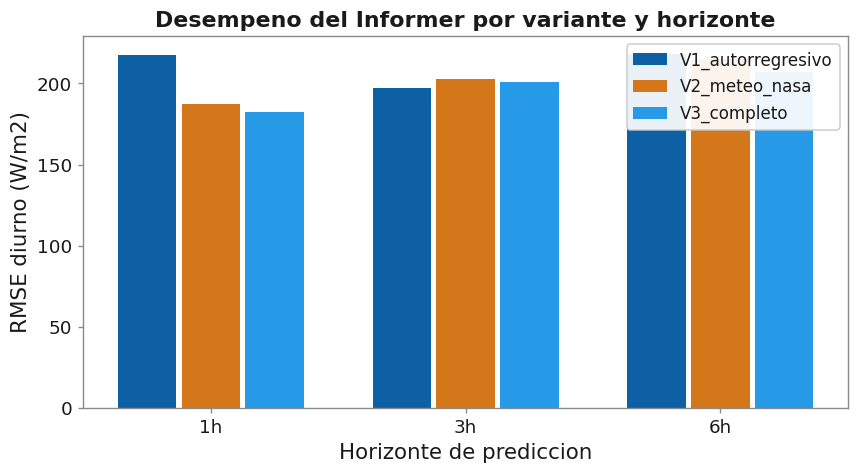

Figura guardada: figuras_SVG/rmse_por_variante.svg


In [ ]:
# 16. Figura 1: RMSE diurno por variante y horizonte
def _val(v, h, col):
    sub = df_met[(df_met.variante == v) & (df_met.horizonte == h)]
    return sub[col].values[0] if len(sub) else np.nan

horizontes = list(PRED_LENS.keys())
variantes  = list(GRUPOS_VARIABLES.keys())
x, w = np.arange(len(horizontes)), 0.25
ANCHO_BARRA = w * 0.92   # deja un hilo de fondo entre barras vecinas
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, v in enumerate(variantes):
    vals = [_val(v, h, 'RMSE_diurno') for h in horizontes]
    ax.bar(x + (i - 1) * w, vals, ANCHO_BARRA, label=v)
ax.set_xticks(x); ax.set_xticklabels(horizontes)
ax.set_xlabel('Horizonte de prediccion'); ax.set_ylabel('RMSE diurno (W/m2)')
ax.set_title('Desempeno del Informer por variante y horizonte')
ax.legend(fontsize=11)
plt.tight_layout()
guardar_figura(fig, 'rmse_por_variante')
plt.show()
print('Figura guardada: figuras_SVG/rmse_por_variante.svg')

  Figura guardada: curvas_aprendizaje.png, .svg y .pdf


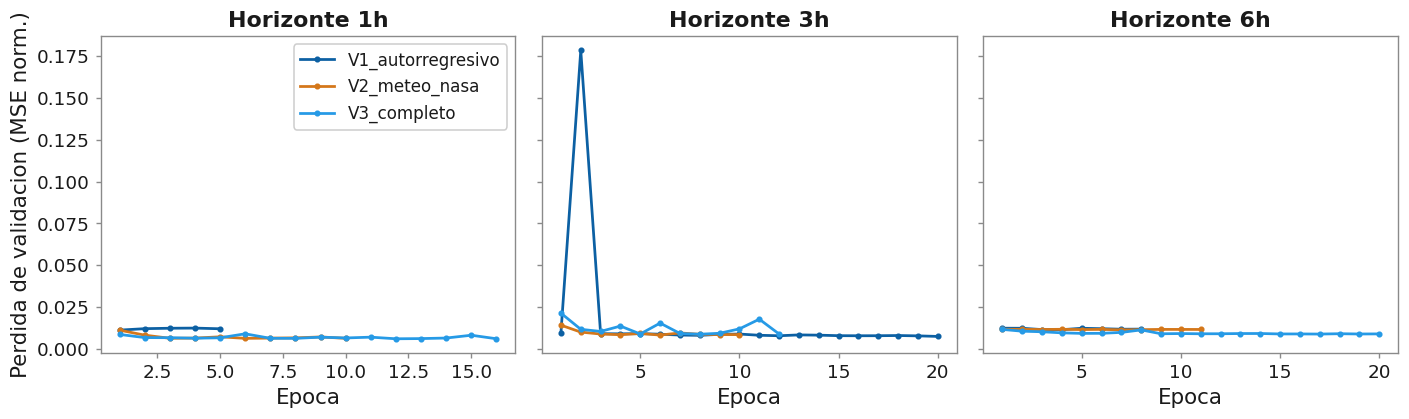

Figura guardada: figuras_SVG/curvas_aprendizaje.svg


In [ ]:
# 17. Figura 2: curvas de aprendizaje
with open(os.path.join(RUTA_RES, f'historias_{MODO}.pkl'), 'rb') as f:
    historias = pickle.load(f)

fig, axes = plt.subplots(1, len(PRED_LENS), figsize=(13, 4), sharey=True)
for ax, h in zip(np.atleast_1d(axes), PRED_LENS):
    hubo = False
    for v in GRUPOS_VARIABLES:
        hist = historias.get(f'{v}__{h}')
        if hist:
            ax.plot(range(1, len(hist['val_loss']) + 1), hist['val_loss'], marker='o', ms=3, label=v)
            hubo = True
    ax.set_title(f'Horizonte {h}'); ax.set_xlabel('Epoca')
    if not hubo:
        ax.text(0.5, 0.5, 'Sin historia\n(modelos cargados)', ha='center', va='center', transform=ax.transAxes)
np.atleast_1d(axes)[0].set_ylabel('Perdida de validacion (MSE norm.)')
np.atleast_1d(axes)[0].legend(fontsize=11)
plt.tight_layout()
guardar_figura(fig, 'curvas_aprendizaje')
plt.show()
print('Figura guardada: figuras_SVG/curvas_aprendizaje.svg')

  Figura guardada: prediccion_vs_observacion.png, .svg y .pdf


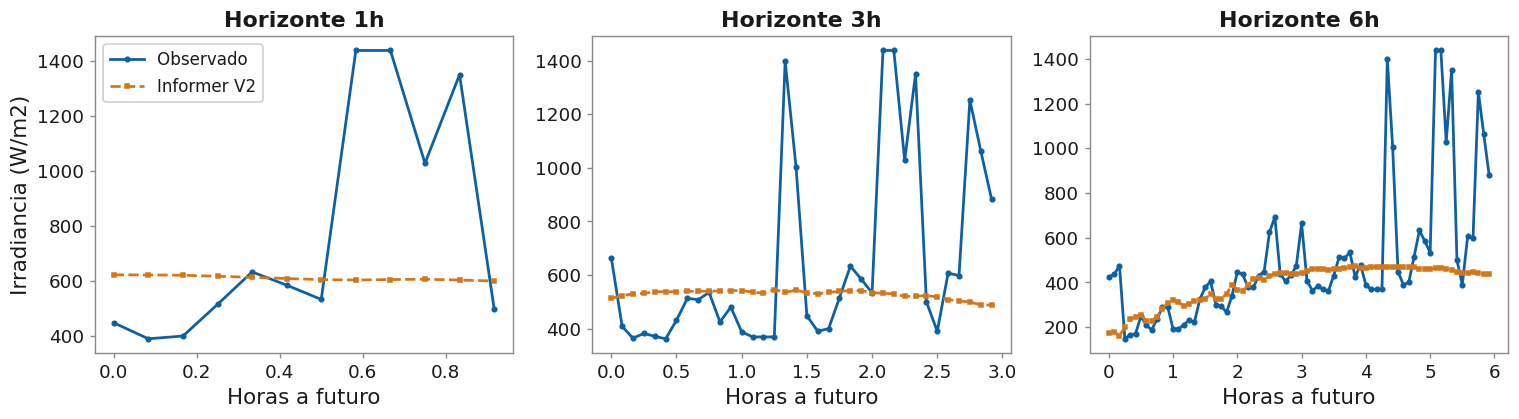

  Figura guardada: dispersion_v2.png, .svg y .pdf


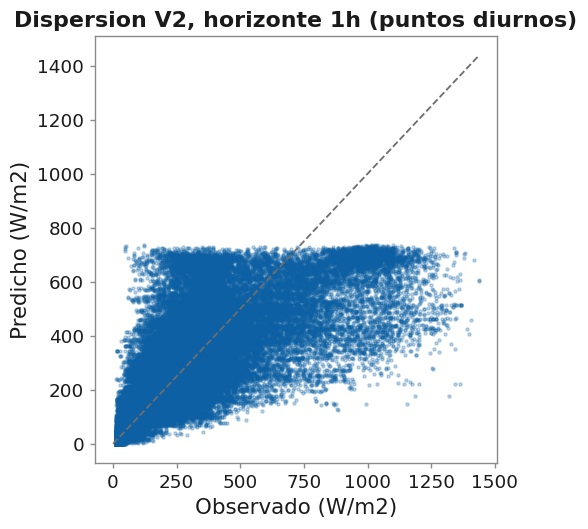

Figuras guardadas: figuras_SVG/prediccion_vs_observacion.svg, figuras_SVG/dispersion_v2.svg


In [ ]:
# 18. Figuras 3 y 4: prediccion frente a observacion y dispersion (variante V2)
# Figura 3: una ventana diurna representativa por horizonte
fig, axes = plt.subplots(1, len(ejemplos), figsize=(14, 4))
for ax, h in zip(np.atleast_1d(axes), ejemplos):
    t_w, p_w, _ig = ejemplos[h]
    idx   = int(np.argmax(t_w.max(axis=1)))           # ventana con mayor irradiancia
    horas = np.arange(t_w.shape[1]) * 5 / 60.0
    ax.plot(horas, t_w[idx], 'o-', ms=3, label='Observado')
    ax.plot(horas, np.clip(p_w[idx], 0, None), 's--', ms=3, label='Informer V2')
    ax.set_title(f'Horizonte {h}'); ax.set_xlabel('Horas a futuro')
np.atleast_1d(axes)[0].set_ylabel('Irradiancia (W/m2)')
np.atleast_1d(axes)[0].legend(fontsize=11)
plt.tight_layout()
guardar_figura(fig, 'prediccion_vs_observacion')
plt.show()

# Figura 4: dispersion predicho-observado (puntos diurnos, horizonte mas corto)
h0 = list(ejemplos.keys())[0]
t_w, p_w, _ig = ejemplos[h0]
m = t_w.ravel() > 10
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(t_w.ravel()[m], np.clip(p_w.ravel(), 0, None)[m], s=4, alpha=0.25)
lim = float(max(t_w.max(), p_w.max()))
ax.plot([0, lim], [0, lim], color=C_GRIS, ls='--', lw=1.2)
ax.set_xlabel('Observado (W/m2)'); ax.set_ylabel('Predicho (W/m2)')
ax.set_title(f'Dispersion V2, horizonte {h0} (puntos diurnos)')
plt.tight_layout()
guardar_figura(fig, 'dispersion_v2')
plt.show()
print('Figuras guardadas: figuras_SVG/prediccion_vs_observacion.svg, figuras_SVG/dispersion_v2.svg')

## Robustez del desempeño por subperíodo

**Añadido en la revisión.** La discusión declara como limitación que el desempeño corresponde a
un único período de prueba. Esta tabla acota mucho esa limitación **sin reentrenar nada**: parte
el conjunto de prueba en trimestres y reporta las métricas en cada uno. Si el desempeño es
estable, el resultado no depende del tramo que tocó evaluar.

In [ ]:
# 19. Robustez por subperiodo del modelo seleccionado
VARIANTE_SEL  = 'V2_meteo_nasa'
HORIZONTE_SEL = '1h'

nombre = f'{VARIANTE_SEL}__{HORIZONTE_SEL}'
ckpt   = os.path.join(RUTA_MODELOS, f'informer_{nombre}_{MODO}.pt')

loaders, enc_in, pred_len, _ = build_loaders(
    VARIANTE_SEL, HORIZONTE_SEL, STRIDE_EV, STRIDE_EV, BATCH)
modelo = build_informer(enc_in, pred_len, HP_BEST)
modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE))

p, t, per = predecir(modelo, loaders['test'])
p_w, t_w, per_w = desnormalizar_rs(p), desnormalizar_rs(t), desnormalizar_rs(per)
ig    = indices_globales(IDX_TEST_INI, IDX_TEST_FIN, pred_len, STRIDE_EV)
p_aj  = ajustar_prediccion(ig, p_w)

tabla_rob = desempeno_por_subperiodo(ig, t_w, p_aj, regla='QS')
print('DESEMPENO DIURNO POR TRIMESTRE DEL CONJUNTO DE PRUEBA')
print('=' * 78)
print(tabla_rob.round(2).to_string(index=False))

cv_rmse = tabla_rob['RMSE'].std() / tabla_rob['RMSE'].mean() * 100
print()
print(f'Coeficiente de variacion del RMSE entre trimestres: {cv_rmse:.2f} %')
if cv_rmse < 15:
    print('Por debajo del 15 %: el desempeno es estable y el resultado no depende')
    print('del tramo de prueba evaluado. Dilo asi en la discusion.')
else:
    print('Por encima del 15 %: hay variabilidad entre trimestres. Relacionala con')
    print('la estacionalidad del recurso al comentarla en la discusion.')

tabla_rob.to_csv(os.path.join(RUTA_RES, 'robustez_subperiodo.csv'), index=False)
print('Tabla guardada: resultados/robustez_subperiodo.csv')

del modelo, loaders
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

DESEMPENO DIURNO POR TRIMESTRE DEL CONJUNTO DE PRUEBA
   periodo    n    MAE   RMSE   R2  sesgo
2024-04-01 3458 112.02 170.65 0.51 -22.23
2024-07-01 8499 135.16 192.69 0.55 -21.48
2024-10-01 6192 148.57 205.20 0.54  -7.81
2025-01-01 8014 120.07 182.63 0.54 -19.44
2025-04-01 8718 110.81 173.31 0.49 -15.39
2025-07-01 8502 122.90 185.32 0.49  -5.99
2025-10-01 6987 136.76 196.47 0.48  -4.91
2026-01-01 6976 131.23 186.21 0.59 -23.06

Coeficiente de variacion del RMSE entre trimestres: 6.17 %
Por debajo del 15 %: el desempeno es estable y el resultado no depende
del tramo de prueba evaluado. Dilo asi en la discusion.
Tabla guardada: resultados/robustez_subperiodo.csv


In [ ]:
# 20. Cifras listas para propagar al documento
sel = df_met[(df_met['variante'] == VARIANTE_SEL)].sort_values('horizonte')

print('CIFRAS DEL MODELO SELECCIONADO — para propagar al documento')
print('=' * 78)
for _, f in sel.iterrows():
    print(f"  Horizonte {f['horizonte']}:")
    print(f"    RMSE global      {f['RMSE']:8.2f} W/m2   (sin ajuste nocturno: {f['RMSE_sin_ajuste']:.2f})")
    print(f"    RMSE diurno      {f['RMSE_diurno']:8.2f} W/m2")
    print(f"    R2 diurno        {f['R2_diurno']:8.3f}")
    print(f"    Ganancia global  {f['skill_RMSE']:8.3f}")
    print(f"    Ganancia diurna  {f['skill_RMSE_diurno']:8.3f}")
print()
print('ESTOS VALORES APARECEN EN CUATRO SITIOS DEL DOCUMENTO:')
print('  - sommario.tex, hacia el final')
print('  - introduction.tex, parrafo de resultados')
print('  - resultados.tex, Tablas 6.9 y 6.10 y el texto de contraste')
print('  - discusion.tex, porcentaje de mejora y cifras de ganancia')
print()
print('Mandaselos a Claude junto con df_met completo y la tabla de robustez.')

CIFRAS DEL MODELO SELECCIONADO — para propagar al documento
  Horizonte 1h:
    RMSE global        128.87 W/m2   (sin ajuste nocturno: 128.87)
    RMSE diurno        187.20 W/m2
    R2 diurno           0.529
    Ganancia global     0.129
    Ganancia diurna     0.161
  Horizonte 3h:
    RMSE global        144.64 W/m2   (sin ajuste nocturno: 144.65)
    RMSE diurno        202.47 W/m2
    R2 diurno           0.451
    Ganancia global     0.255
    Ganancia diurna     0.304
  Horizonte 6h:
    RMSE global        165.49 W/m2   (sin ajuste nocturno: 165.57)
    RMSE diurno        215.13 W/m2
    R2 diurno           0.381
    Ganancia global     0.321
    Ganancia diurna     0.399

ESTOS VALORES APARECEN EN CUATRO SITIOS DEL DOCUMENTO:
  - sommario.tex, hacia el final
  - introduction.tex, parrafo de resultados
  - resultados.tex, Tablas 6.9 y 6.10 y el texto de contraste
  - discusion.tex, porcentaje de mejora y cifras de ganancia

Mandaselos a Claude junto con df_met completo y la tabla de

## Resumen y entrega para el documento

Al ejecutar este notebook se obtienen los insumos de la Actividad 3 para que Juan redacte la seccion de Resultados:

- `resultados/metricas_variantes.csv` — tabla de MAE, RMSE, R2 (global y diurno), sMAPE diurno y *skill* frente a persistencia, por variante y horizonte.
- `figuras/rmse_por_variante.png` — comparacion central entre V1, V2 y V3.
- `figuras/curvas_aprendizaje.png` — evidencia de entrenamiento y validacion.
- `figuras/prediccion_vs_observacion.png` y `figuras/dispersion_v3.png` — desempeno cualitativo del modelo.
- `modelos/informer_*_{MODO}.pt` — pesos entrenados, reproducibles.

**Lectura sugerida para el documento:** la comparacion V1 -> V2 -> V3 cuantifica el aporte de NASA POWER (la diferencia V2 -> V3 aisla el valor de la irradiancia satelital, en linea con Taha et al., 2025); el *skill* positivo frente a persistencia justifica el uso del modelo; y el aumento del error de 1 h a 6 h documenta el limite de horizonte util.

**Recomendacion:** ejecutar primero en `MODO = 'piloto'` para validar el flujo; luego `MODO = 'completo'` para la corrida definitiva. Recordar que `hp_best.pkl` debe provenir de la corrida completa del Notebook 05.